## Paso 1: Cargar los datos

En este paso, importamos los archivos CSV a DataFrames usando Pandas. También importamos las librerias con las que vamos a trabajar.

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv('Entregable1', low_memory=False)

## Paso 2: Identificar las variables clave para el análisis

Identificamos las variables que nos interesan, calculamos la media y las agrupamos en series para graficarlas.

In [19]:
segment_vs = df.groupby('SEGMENT')['TOTAL_VALUE_SALES'].mean().sort_values(ascending=False)
segment_us = df.groupby('SEGMENT')['TOTAL_UNIT_SALES'].mean().sort_values(ascending=False)

In [21]:
brand_vs = df.groupby('BRAND')['TOTAL_VALUE_SALES'].mean().sort_values(ascending=False)
brand_us = df.groupby('BRAND')['TOTAL_UNIT_SALES'].mean().sort_values(ascending=False)

In [23]:
region_vs = df.groupby('REGION')['TOTAL_VALUE_SALES'].mean().sort_values(ascending=False)
region_us = df.groupby('REGION')['TOTAL_UNIT_SALES'].mean().sort_values(ascending=False)

## Paso 3: Visualizar la distribución de ventas

En este paso generamos gráficos de barra y boxplots para visualizar la distribución de ventas por diferentes categorías.

C:\Users\emanu\AppData\Local\Temp\ipykernel_25892\3152225270.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(segment_vs.index, rotation=75)
C:\Users\emanu\AppData\Local\Temp\ipykernel_25892\3152225270.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(segment_us.index, rotation=75)


<function matplotlib.pyplot.show(close=None, block=None)>

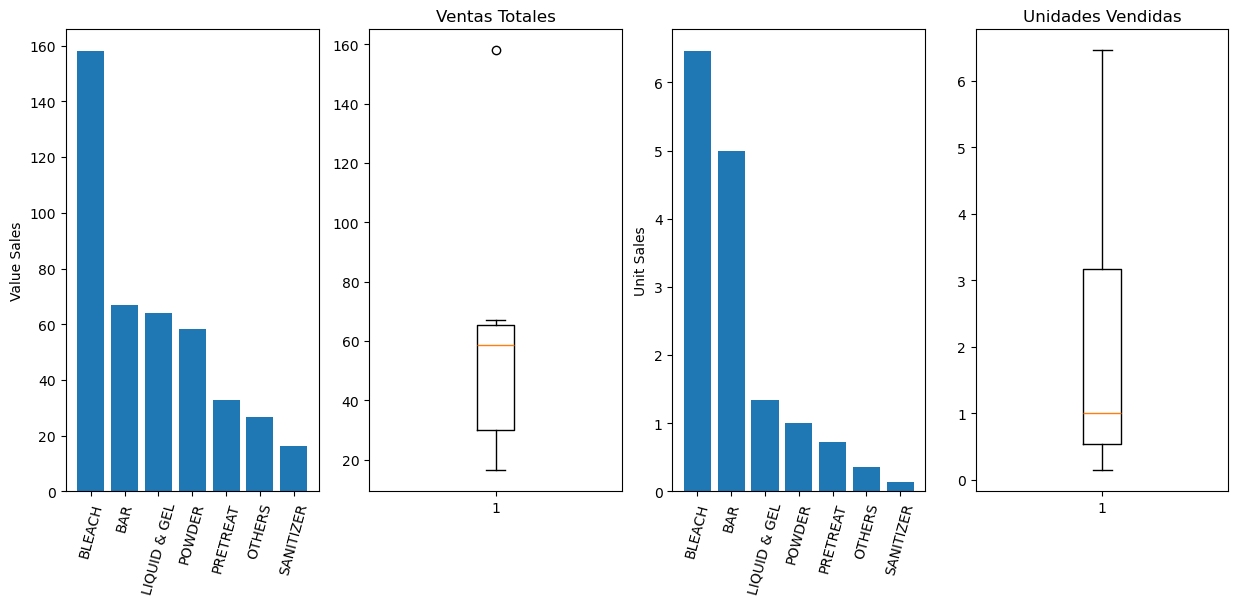

In [443]:
fig, ax = plt.subplots(1, 4, figsize=(15, 6))
ax[0].bar(segment_vs.index, segment_vs)
ax[0].set_ylabel('Value Sales')
ax[2].bar(segment_us.index, segment_us)
ax[2].set_ylabel('Unit Sales')
ax[1].boxplot(segment_vs)
ax[1].set_title('Ventas Totales')
ax[3].boxplot(segment_us)
ax[3].set_title('Unidades Vendidas')
ax[0].set_xticklabels(segment_vs.index, rotation=75)
ax[2].set_xticklabels(segment_us.index, rotation=75)
plt.show()

In [427]:
fig.savefig('ventas_segmentos.png')

Podemos observar por ejemplo que el segmento 'BLEACH' es el que mayor ganancia en promedio ha generado y por una diferencia bastante grande en comparación con el resto de segmentos, a pesar de que el total de unidades vendidas no es tan diferente entre los segmentos 'BLEACH' y 'BAR'.

C:\Users\emanu\AppData\Local\Temp\ipykernel_25892\2926663864.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(brand_vs.index, rotation=90)
C:\Users\emanu\AppData\Local\Temp\ipykernel_25892\2926663864.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(brand_us.index, rotation=90)


<function matplotlib.pyplot.show(close=None, block=None)>

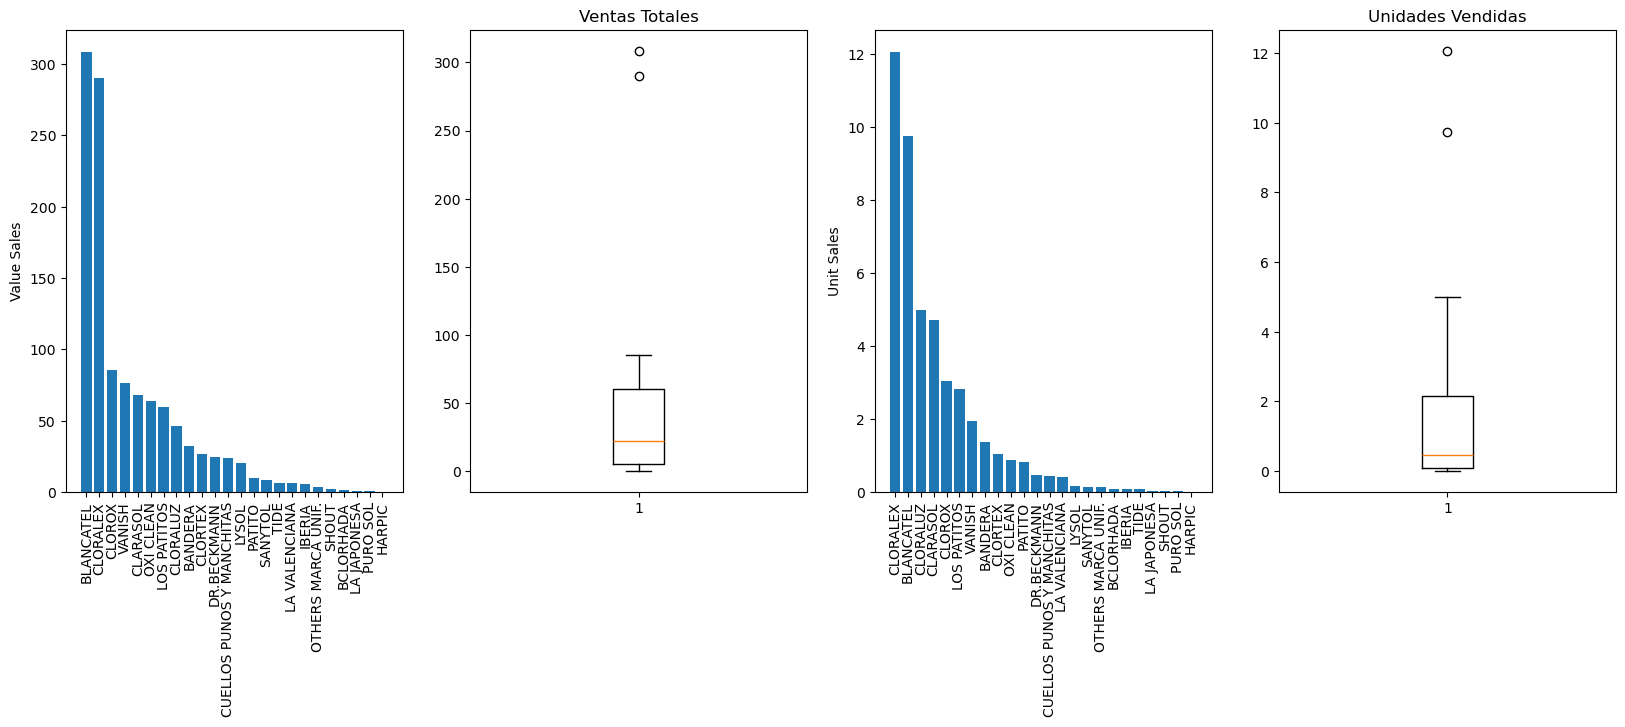

In [305]:
fig, ax = plt.subplots(1, 4, figsize=(20, 6))
ax[0].bar(brand_vs.index, brand_vs)
ax[0].set_ylabel('Value Sales')
ax[2].bar(brand_us.index, brand_us)
ax[2].set_ylabel('Unit Sales')
ax[1].boxplot(brand_vs)
ax[1].set_title('Ventas Totales')
ax[3].boxplot(brand_us)
ax[3].set_title('Unidades Vendidas')
ax[0].set_xticklabels(brand_vs.index, rotation=90)
ax[2].set_xticklabels(brand_us.index, rotation=90)
plt.show()

In [ ]:
fig.savefig('ventas_marcas.png')

Así mismo observamos que las marcas 'BLANCATEL' y 'CLORALEX' son las que reportan las ganancias más sobresalientes, 'BLANCATEL' habiendo generado más ganancias en promedio a pesar de que 'CLORALEX' vendió más unidades.

C:\Users\emanu\AppData\Local\Temp\ipykernel_25892\657204485.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(region_vs.index, rotation=90)
C:\Users\emanu\AppData\Local\Temp\ipykernel_25892\657204485.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(region_us.index, rotation=90)


<function matplotlib.pyplot.show(close=None, block=None)>

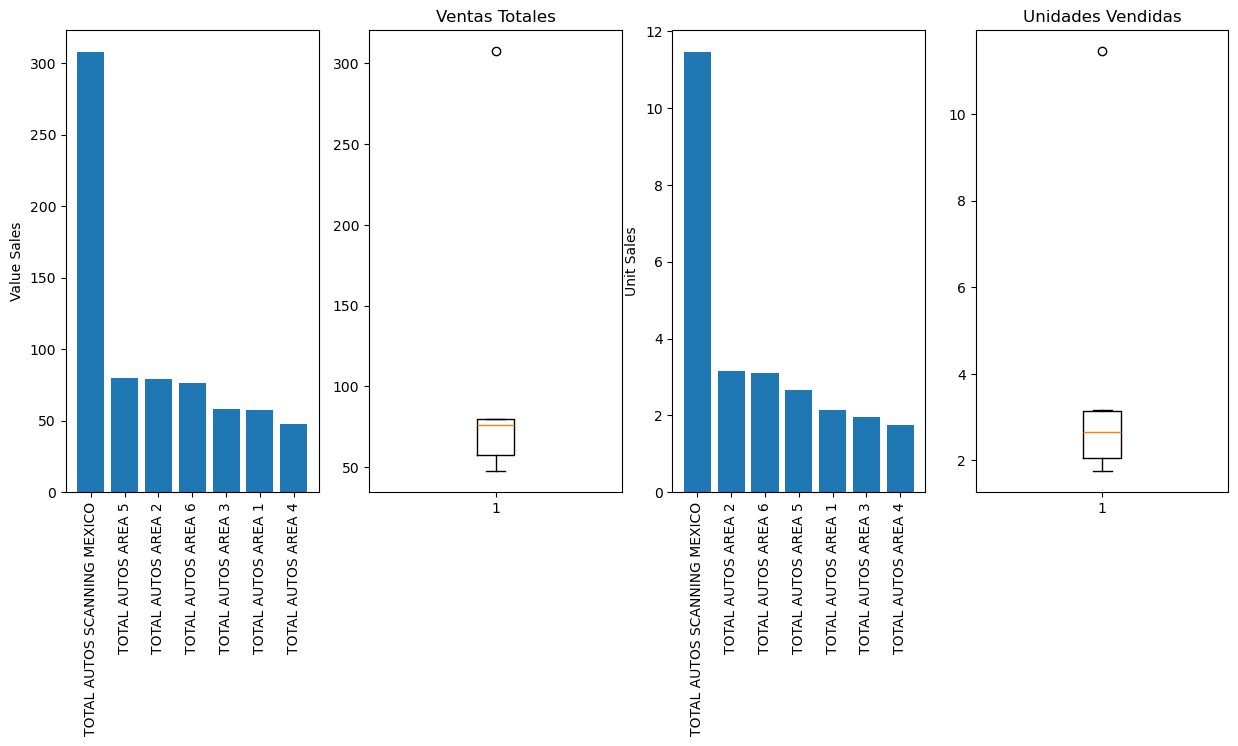

In [307]:
fig, ax = plt.subplots(1, 4, figsize=(15, 6))
ax[0].bar(region_vs.index, region_vs)
ax[0].set_ylabel('Value Sales')
ax[2].bar(region_us.index, region_us)
ax[2].set_ylabel('Unit Sales')
ax[1].boxplot(region_vs)
ax[1].set_title('Ventas Totales')
ax[3].boxplot(region_us)
ax[3].set_title('Unidades Vendidas')
ax[0].set_xticklabels(region_vs.index, rotation=90)
ax[2].set_xticklabels(region_us.index, rotation=90)
plt.show()

In [ ]:
fig.savefig('ventas_regiones.png')

También podemos destacar que la región 'TOTAL AUTOS SCANNING MEXICO' lidera las ventas totales por un margen muy grande, mientras que el resto de regiones se mantienen más o menos cerca del mismo nivel de ventas.

## Paso 4: Analizar la tendencia de ventas en el tiempo

En este paso filtramos las ventas por diferentes marcas, regiones y segmentos para analizar cómo han cambiado las ventas a lo largo del tiempo.

In [31]:
df['DATE'] = pd.to_datetime(df['DATE'])
df['MONTH'] = df['DATE'].dt.to_period('M')

In [494]:
ventas_mes = df.groupby('MONTH')['TOTAL_VALUE_SALES'].sum()

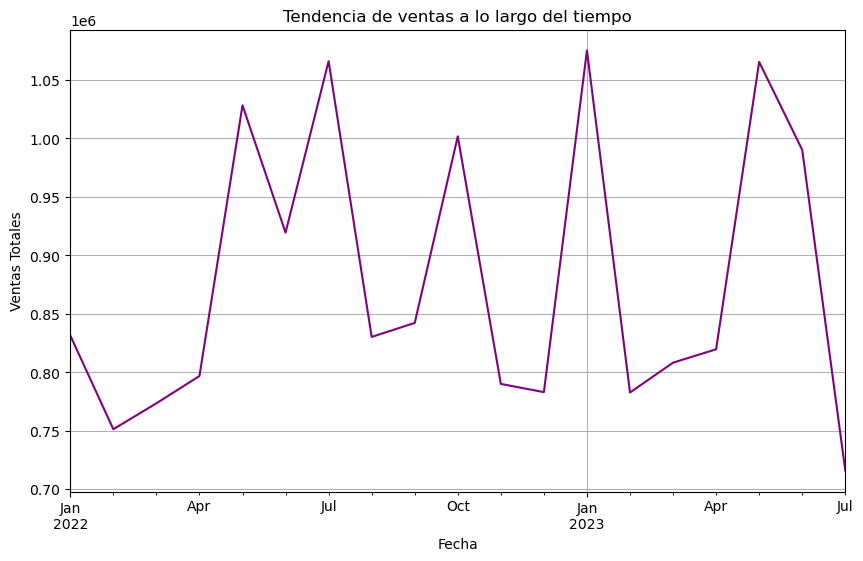

In [35]:
plt.figure(figsize=(10,6))
ventas_mes.plot(kind='line', color='purple')
plt.title('Tendencia de ventas a lo largo del tiempo')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')
plt.grid(True)
plt.show()

In [ ]:
fig.savefig('tendencia_ventas_tiempo.png')

Este gráfico indica la tendencia de ventas totales a lo largo del tiempo, destacando que en Enero de 2023 se registró el punto máximo de ventas y en Julio de 2023 el punto mínimo.

In [83]:
sg = df.groupby(['SEGMENT', 'DATE'])['TOTAL_VALUE_SALES'].sum()
sg = sg.unstack()
sg = sg.transpose()

<Figure size 1500x600 with 0 Axes>

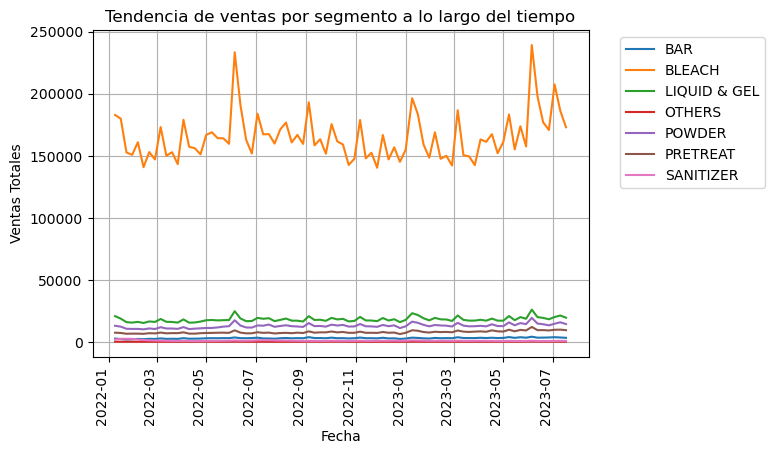

In [159]:
plt.figure(figsize=(15,6))
sg.plot(kind='line')
plt.title('Ventas por segmento a lo largo del tiempo')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')
plt.xticks(rotation=90)
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
fig.savefig('ventas_segmentos_tiempo.png')

En esta gráfica podemos obsvervar la variación de las ventas por segmento de Enero de 2022 hasta Julio de 2023. Podemos apreciar que el segmento 'BLEACH' lidera en volumen de ventas, aunque de manera general todos los segmentos siguen la misma tendencia. No se aprecia un crecimiento o disminución importante en este lapso de tiempo. Solo se podrían resaltar las temporadas de ventas más altas siendo aproximadamente en Junio de 2022 y 2023.

In [93]:
br = df.groupby(['BRAND', 'DATE'])['TOTAL_VALUE_SALES'].sum()
br = br.unstack()
br = br.transpose()

<Figure size 1500x600 with 0 Axes>

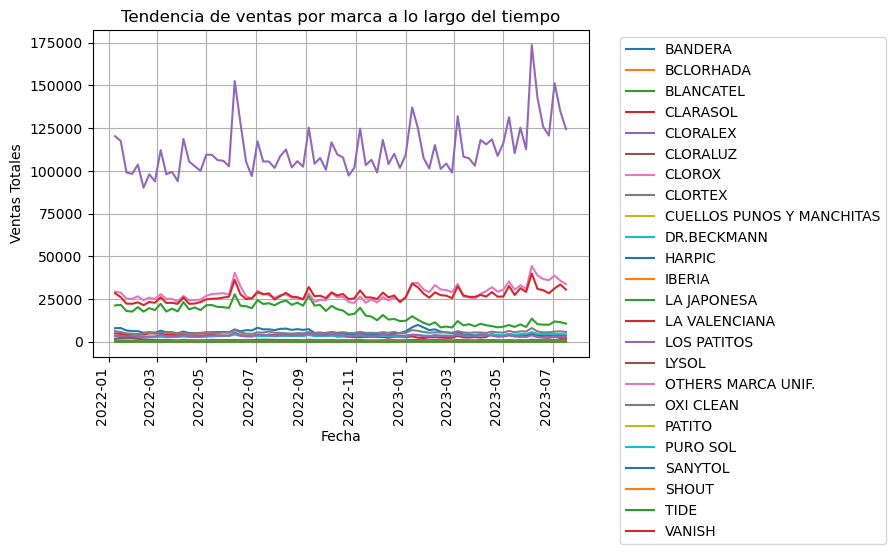

In [161]:
plt.figure(figsize=(15,6))
br.plot(kind='line')
plt.title('Ventas por marca a lo largo del tiempo')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')
plt.xticks(rotation=90)
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
fig.savefig('ventas_marca_tiempo.png')

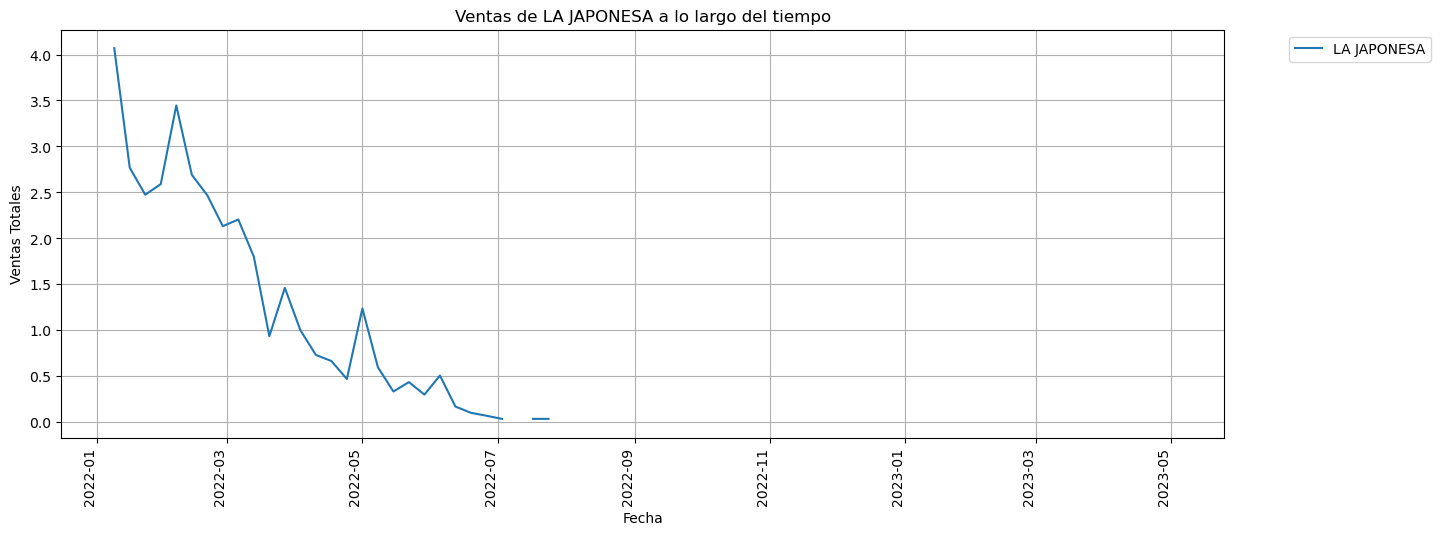

In [513]:
plt.figure(figsize=(15,6))
br['LA JAPONESA'].plot(kind='line')
plt.title('Ventas de LA JAPONESA a lo largo del tiempo')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')
plt.xticks(rotation=90)
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

En estas gráficas podemos obsvervar la variación de las ventas por marca de Enero de 2022 hasta Julio de 2023. 
Observamos que la marca 'CLORALEX' lidera en volumen de ventas. De manera general todas las marcas siguen la misma tendencia a excepción de 'LA JAPONESA', la cual tuvo una caída importante, sin embargo cabe recalcar que no hay datos de ventas de esa marca después de Julio 2022 por lo que no se sabe si esta dismunición fue porque se descontinuó o por otras razones. Se aprecia un crecimiento pequeño en este lapso de tiempo. Los puntos máximos coinciden con la gráfica anterior de los segmentos, siendo aproximadamente en Junio de 2022 y 2023.

In [103]:
rg = df.groupby(['REGION', 'DATE'])['TOTAL_VALUE_SALES'].sum()
rg = rg.unstack()
rg = rg.transpose()

<Figure size 1500x600 with 0 Axes>

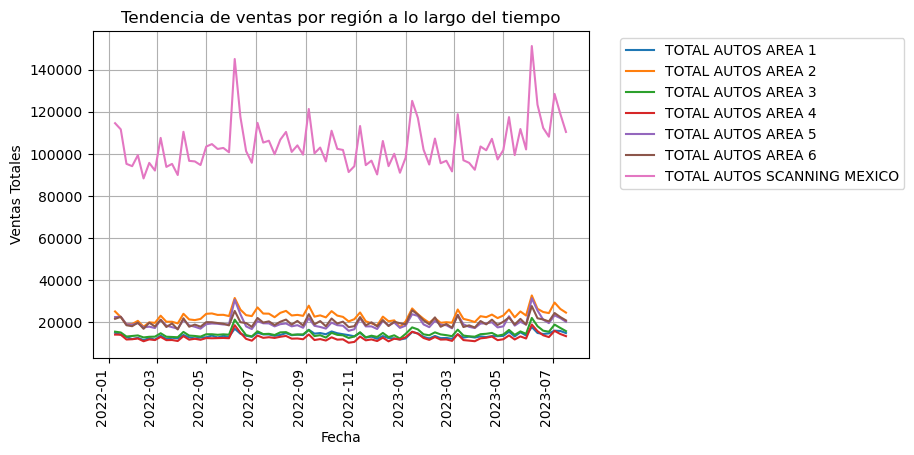

In [165]:
plt.figure(figsize=(15,6))
rg.plot(kind='line')
plt.title('Ventas por región a lo largo del tiempo')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')
plt.xticks(rotation=90)
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
fig.savefig('ventas_region_tiempo.png')

Similar a la gráfica de segmentos, podemos apreciar que hay un área 'TOTAL AUTOS SCANNING MEXICO' que lidera en volumen de ventas y que de manera general todos las áreas siguen la misma tendencia. No se aprecia un crecimiento o disminución importante en este lapso de tiempo. Las temporadas de ventas más altas siguen siendo aproximadamente en Junio de 2022 y 2023.

## Paso 5: Explorar la relación entre diferentes variables

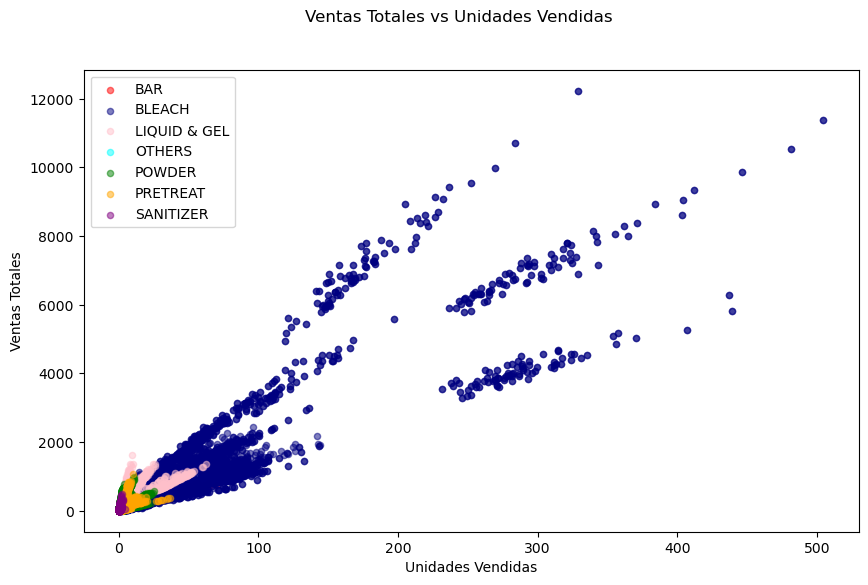

In [556]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'BAR': 'Red', 'BLEACH': 'Navy', 'LIQUID & GEL': 'Pink', 'OTHERS': 'Cyan', 'POWDER': 'Green', 'PRETREAT': 'ORANGE', 'SANITIZER': 'Purple'}
for kind, data in df.groupby('SEGMENT'):
    data.plot(kind='scatter', x='TOTAL_UNIT_SALES', y='TOTAL_VALUE_SALES', label=kind, color=colors[kind], alpha=0.5, ax=ax)

ax.set(xlabel='Unidades Vendidas', ylabel='Ventas Totales')
fig.suptitle('Ventas Totales vs Unidades Vendidas')
plt.show()

In [ ]:
fig.savefig('ventas_vs_unidades.png')

En este gráfico observamos que existe una relación no lineal entre las ventas totales y las unidades vendidas y por lo tanto descartamos correlaciones significativas entre estas variables.

## Paso 6: Visualizar la distribución geográfica de las ventas

In [407]:
rg_apilada = df.groupby(['REGION', 'YEAR'])['TOTAL_VALUE_SALES'].sum()
rg_apilada = rg_apilada.unstack()

<Figure size 640x480 with 0 Axes>

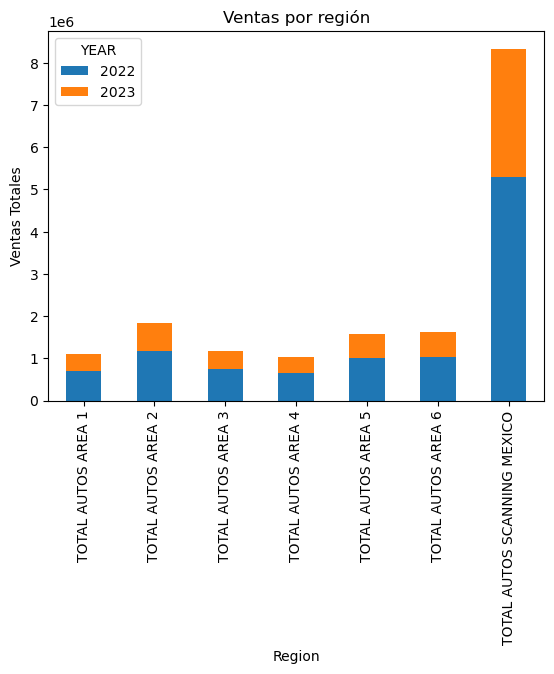

In [395]:
plt.figure()
rg_apilada.plot(kind='bar', stacked=True)
plt.title('Ventas por región')
plt.xlabel('Region')
plt.ylabel('Ventas Totales')
plt.xticks(rotation=90)
plt.show()

In [ ]:
fig.savefig('ventas_rg_apilada.png')

En este gráfico de barras apiladas podemos visualizar las ventas por región, identificando 'TOTAL AUTOS SCANNING MEXICO' como la región con el mayor rendimiento en ambos años, seguida de 'TOTAL AUTOS AREA 2'.

## Paso 7: Identificar posibles outliers y anomalías

<function matplotlib.pyplot.show(close=None, block=None)>

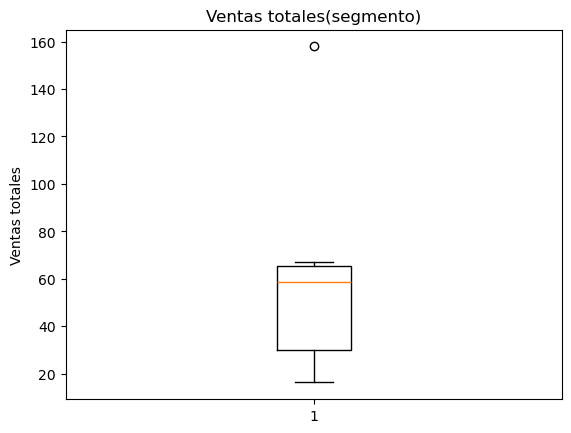

In [415]:
plt.figure()
plt.boxplot(segment_vs)
plt.ylabel('Ventas totales')
plt.title('Ventas totales(segmento)')
plt.show

In [ ]:
fig.savefig('boxplot_segmento.png')

<function matplotlib.pyplot.show(close=None, block=None)>

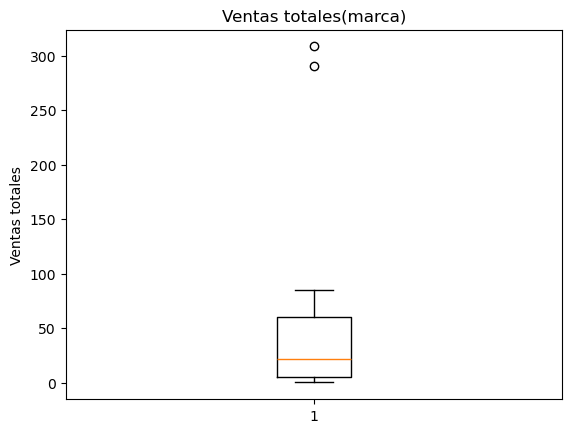

In [417]:
plt.figure()
plt.boxplot(brand_vs)
plt.ylabel('Ventas totales')
plt.title('Ventas totales(marca)')
plt.show

In [ ]:
fig.savefig('boxplot_marca.png')

<function matplotlib.pyplot.show(close=None, block=None)>

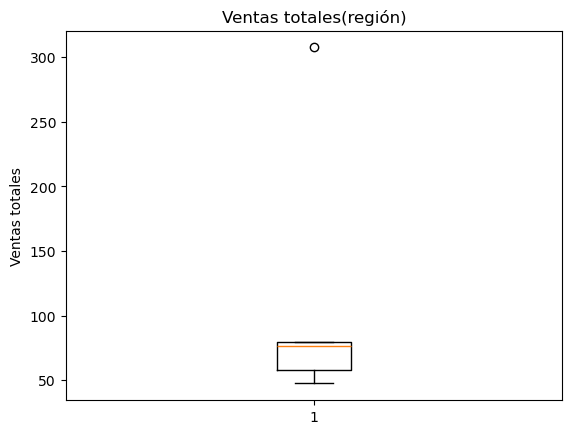

In [419]:
plt.figure()
plt.boxplot(region_vs)
plt.ylabel('Ventas totales')
plt.title('Ventas totales(región)')
plt.show

In [ ]:
fig.savefig('boxplot_region.png')

En esta parte simplemente separamos los gráficos tipo boxplot del Paso 3 para que se pudieran observar de mejor manera.

## Paso 8: Documentar los insights obtenidos

Las observaciones se anotaron debajo de cada gráfica para tener mejor comprensión de las mismas.

## Paso 9: Guardar las visualizaciones

Se guardaron todas las imagenes mediante el método plt.savefig()